In [1]:
# 步骤1：环境准备
import pandas as pd
import numpy as np
import yfinance as yf
import matplotlib.pyplot as plt
import warnings
warnings.filterwarnings('ignore')

# 设置中文字体显示
plt.rcParams['font.sans-serif'] = ['Arial Unicode MS']  # macos
# plt.rcParams['font.sans-serif'] = ['SimHei']  # windows
plt.rcParams['axes.unicode_minus'] = False

In [2]:
# 步骤2：参数设置
symbol = 'AAPL'        # 股票代码
period = '2y'          # 时间周期
rsi_period = 14        # RSI周期
kdj_period = 9         # KDJ周期

In [3]:
# 步骤3：获取股票数据
ticker = yf.Ticker(symbol)
df = ticker.history(period=period)
print(f"✅ 数据获取完成，共 {len(df)} 个交易日")

✅ 数据获取完成，共 502 个交易日


In [4]:
# 步骤4：正确计算RSI指标（基于涨跌幅百分比）
price_change = df['Close'].pct_change() * 100  # 涨跌幅百分比

gain = (price_change.where(price_change > 0, 0)).rolling(window=rsi_period).mean()
loss = (-price_change.where(price_change < 0, 0)).rolling(window=rsi_period).mean()

rs = gain / loss
df['RSI'] = 100 - (100 / (1 + rs))
print("✅ RSI指标计算完成")

✅ RSI指标计算完成


In [5]:
# 步骤5：计算KDJ指标（简单替代版）
low_min = df['Low'].rolling(window=kdj_period).min()
high_max = df['High'].rolling(window=kdj_period).max()
rsv = (df['Close'] - low_min) / (high_max - low_min) * 100

# 用50填充RSV的NaN值
rsv_filled = rsv.fillna(50)

# 递归计算K、D
K, D = [50], [50]
for r in rsv_filled.iloc[1:]:
    k = (2/3) * K[-1] + (1/3) * r
    d = (2/3) * D[-1] + (1/3) * k
    K.append(k)
    D.append(d)

df['K'], df['D'] = K, D
df['J'] = 3 * df['K'] - 2 * df['D']
print("✅ KDJ指标计算完成")

✅ KDJ指标计算完成


In [6]:
# 步骤6：分析信号
# RSI信号
df['RSI_oversold'] = df['RSI'] < 20    # 超卖信号
df['RSI_overbought'] = df['RSI'] > 80  # 超买信号

# KDJ信号
df['KDJ_golden_cross'] = (df['K'] > df['D']) & (df['K'].shift(1) <= df['D'].shift(1))  # 金叉
df['KDJ_death_cross'] = (df['K'] < df['D']) & (df['K'].shift(1) >= df['D'].shift(1))   # 死叉
print("✅ 技术信号分析完成")

✅ 技术信号分析完成


In [7]:
# 步骤7：统计指标

# RSI信号统计 - 识别信号的开始
rsi_oversold_count = ((df['RSI_oversold']) & (~df['RSI_oversold'].shift(1, fill_value=False))).sum()
rsi_overbought_count = ((df['RSI_overbought']) & (~df['RSI_overbought'].shift(1, fill_value=False))).sum()

# KDJ信号统计 - 金叉死叉已经是瞬时信号，可以直接统计
kdj_golden_count = df['KDJ_golden_cross'].sum()
kdj_death_count = df['KDJ_death_cross'].sum()

# 步骤8：显示统计结果
print(f"\n📊 RSI{rsi_period} 统计")
print("=" * 40)
print(f"  超卖信号出现: {rsi_oversold_count} 次")
print(f"  超买信号出现: {rsi_overbought_count} 次")

print(f"\n📊 KDJ{kdj_period} 统计")
print("=" * 40)
print(f"  金叉次数: {kdj_golden_count} 次")
print(f"  死叉次数: {kdj_death_count} 次")


📊 RSI14 统计
  超卖信号出现: 6 次
  超买信号出现: 10 次

📊 KDJ9 统计
  金叉次数: 35 次
  死叉次数: 35 次


In [11]:
# 步骤9：分析当前状态
latest = df.iloc[-1]

print(f"\n🎯 {symbol} 当前技术指标状态")
print("=" * 50)

# RSI当前状态
rsi_value = latest['RSI']
if rsi_value < 20:
    rsi_status = "🔴 超卖"
elif rsi_value > 80:
    rsi_status = "🟢 超买"
else:
    rsi_status = "🟡 中性"

print(f"RSI{rsi_period}: {rsi_value:.2f} - {rsi_status}")

# KDJ当前状态
k, d, j = latest['K'], latest['D'], latest['J']
kdj_trend = "上升" if k > d else "下降"
print(f"KDJ{kdj_period}: K={k:.2f}, D={d:.2f}, J={j:.2f}")
print(f"KDJ趋势: {kdj_trend}")

# 综合判断
if rsi_value < 20 and k > d:
    overall = "🟢 强烈买入信号"
elif rsi_value > 80 and k < d:
    overall = "🔴 强烈卖出信号"
elif (rsi_value < 30 and k > d):
    overall = "🟡 偏多信号"
elif (rsi_value > 70 and k < d):
    overall = "🟠 偏空信号"
else:
    overall = "⚪ 中性"

print(f"\n综合判断: {overall}")


🎯 AAPL 当前技术指标状态
RSI14: 80.16 - 🟢 超买
KDJ9: K=85.20, D=85.83, J=83.92
KDJ趋势: 下降

综合判断: 🔴 强烈卖出信号



📈 绘制技术分析图表...


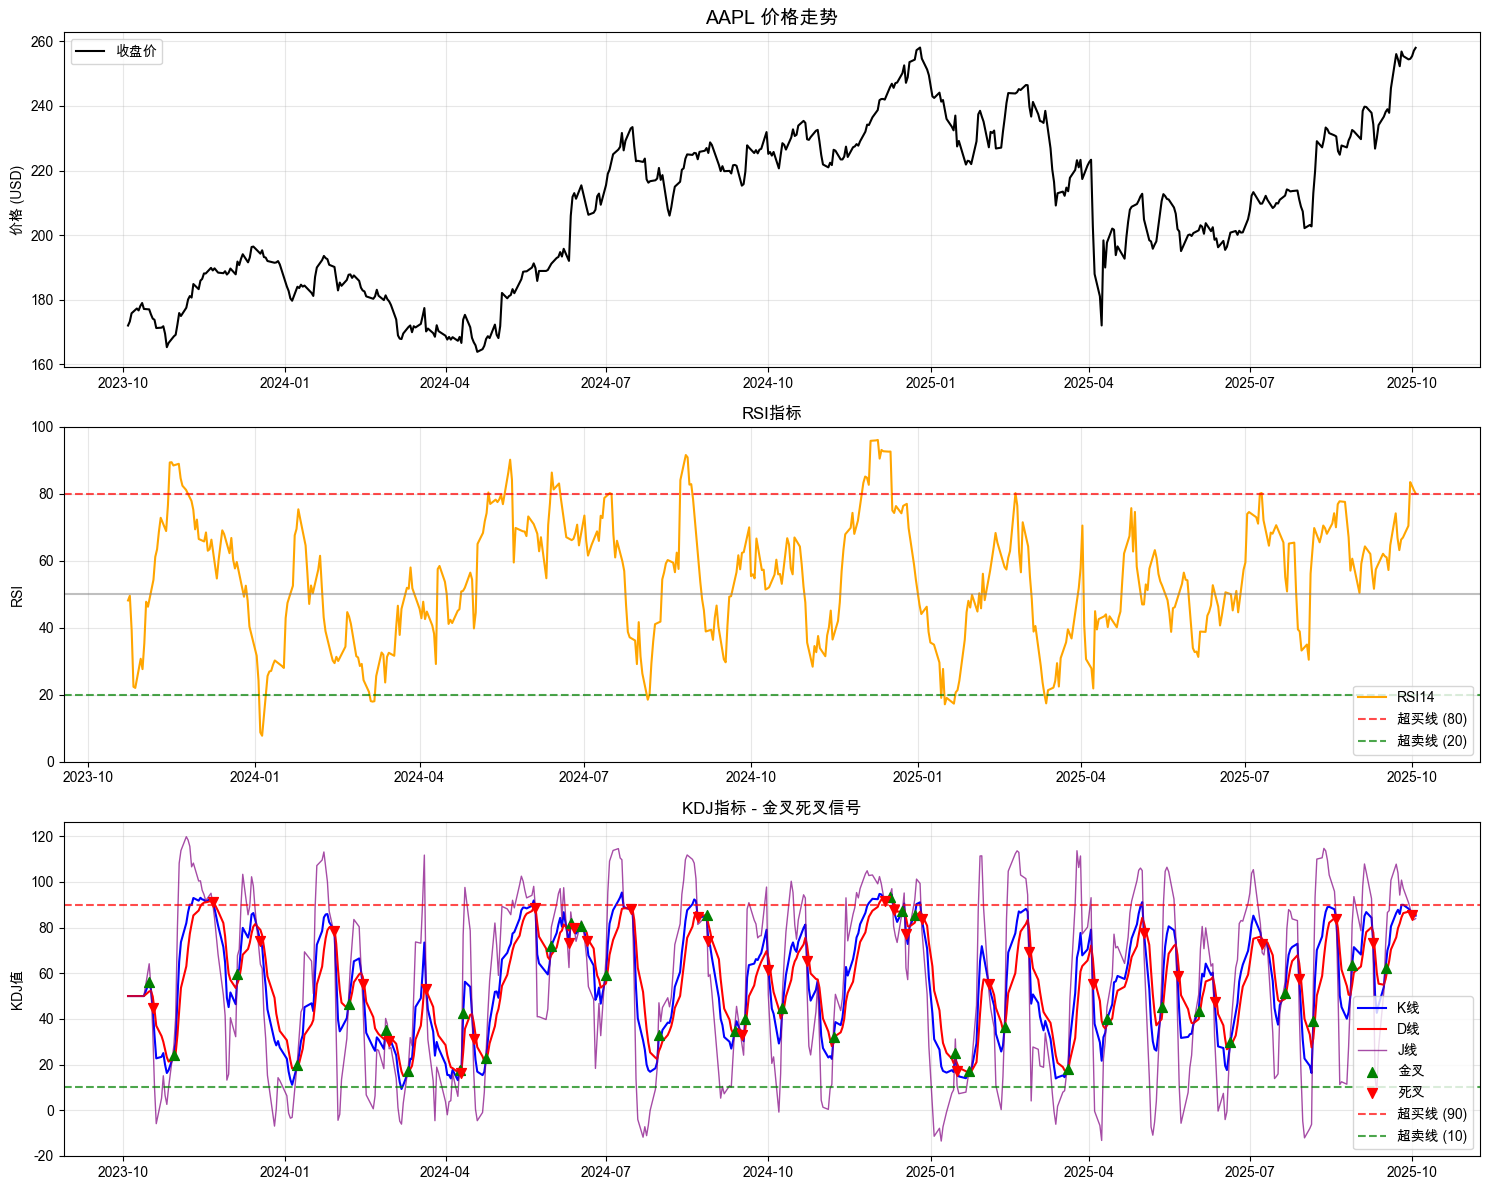

✅ RSI & KDJ 分析完成！


In [12]:
# 步骤10：绘制图表
print(f"\n📈 绘制技术分析图表...")

fig, (ax1, ax2, ax3) = plt.subplots(3, 1, figsize=(15, 12))

# 价格图表
ax1.plot(df.index, df['Close'], label='收盘价', linewidth=1.5, color='black')
ax1.set_title(f'{symbol} 价格走势', fontsize=14, fontweight='bold')
ax1.set_ylabel('价格 (USD)')
ax1.legend()
ax1.grid(True, alpha=0.3)

# RSI图表
ax2.plot(df.index, df['RSI'], label=f'RSI{rsi_period}', linewidth=1.5, color='orange')
ax2.axhline(y=80, color='red', linestyle='--', alpha=0.7, label='超买线 (80)')
ax2.axhline(y=20, color='green', linestyle='--', alpha=0.7, label='超卖线 (20)')
ax2.axhline(y=50, color='gray', linestyle='-', alpha=0.5)
ax2.set_ylabel('RSI')
ax2.set_ylim(0, 100)
ax2.legend()
ax2.grid(True, alpha=0.3)
ax2.set_title('RSI指标', fontsize=12)

# KDJ图表
ax3.plot(df.index, df['K'], label='K线', linewidth=1.5, color='blue')
ax3.plot(df.index, df['D'], label='D线', linewidth=1.5, color='red')
ax3.plot(df.index, df['J'], label='J线', linewidth=1, color='purple', alpha=0.7)

# 标记KDJ金叉（买入信号）
golden_cross_points = df[df['KDJ_golden_cross']]
ax3.scatter(golden_cross_points.index, golden_cross_points['K'], 
           color='green', marker='^', s=50, label='金叉', zorder=5)

# 标记KDJ死叉（卖出信号）
death_cross_points = df[df['KDJ_death_cross']]
ax3.scatter(death_cross_points.index, death_cross_points['K'], 
           color='red', marker='v', s=50, label='死叉', zorder=5)

ax3.axhline(y=90, color='red', linestyle='--', alpha=0.7, label='超买线 (90)')
ax3.axhline(y=10, color='green', linestyle='--', alpha=0.7, label='超卖线 (10)')
ax3.set_ylabel('KDJ值')
ax3.legend()
ax3.grid(True, alpha=0.3)
ax3.set_title('KDJ指标 - 金叉死叉信号', fontsize=12)

plt.tight_layout()
plt.show()

print("✅ RSI & KDJ 分析完成！")